In [ ]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=927410001eb16bdf39fbf81375b2301b66e0ae7e8386ad854b4b8dad33c0204b
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [ ]:
import os
import glob

print("Files in Colab:")
print(os.listdir('/content'))

print("\nCSV files:")
print(glob.glob('/content/*.csv'))

Files in Colab:
['.config', 'country_data.csv', 'sample_data']

CSV files:
['/content/country_data.csv']


In [ ]:
import pandas as pd

df = pd.read_csv('/content/country_data.csv')

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (204, 38)

Column names:
['gdp', 'sex_ratio', 'surface_area', 'life_expectancy_male', 'unemployment', 'imports', 'homicide_rate', 'currency', 'iso2', 'employment_services', 'employment_industry', 'urban_population_growth', 'secondary_school_enrollment_female', 'employment_agriculture', 'capital', 'forested_area', 'exports', 'life_expectancy_female', 'post_secondary_enrollment_female', 'post_secondary_enrollment_male', 'primary_school_enrollment_female', 'infant_mortality', 'gdp_growth', 'threatened_species', 'population', 'urban_population', 'secondary_school_enrollment_male', 'name', 'pop_growth', 'region', 'pop_density', 'internet_users', 'gdp_per_capita', 'fertility', 'refugees', 'primary_school_enrollment_male', 'co2_emissions', 'tourists']

First 5 rows:


,gdp,sex_ratio,surface_area,life_expectancy_male,unemployment,imports,homicide_rate,currency,iso2,employment_services,...,pop_growth,region,pop_density,internet_users,gdp_per_capita,fertility,refugees,primary_school_enrollment_male,co2_emissions,tourists
0,20514.0,105.4,652864.0,62.8,11.2,8370.0,6.7,"{'code': 'AFN', 'name': 'Afghani'}",AF,39.4,...,2.5,Southern Asia,59.6,13.5,551.9,4.6,2826.4,124.2,NaN,NaN
1,15059.0,103.7,28748.0,76.7,12.8,5908.0,2.3,"{'code': 'ALL', 'name': 'Lek'}",AL,43.7,...,-0.1,Southern Europe,105.0,71.8,5223.8,1.6,4.3,105.2,4.3,5340.0
2,173757.0,102.1,2381741.0,75.4,11.5,45140.0,1.4,"{'code': 'DZD', 'name': 'Algerian Dinar'}",DZ,59.6,...,2.0,Northern Africa,18.4,49.0,4114.7,3.0,99.5,112.4,130.5,2657.0
3,3238.0,102.3,468.0,NaN,NaN,1538.0,0.0,"{'code': 'EUR', 'name': 'Euro'}",AD,NaN,...,-0.2,Southern Europe,164.2,91.6,42051.6,1.2,NaN,NaN,NaN,3042.0
4,105902.0,97.9,1246700.0,57.8,6.8,21340.0,4.8,"{'code': 'AOA', 'name': 'Kwanza'}",AO,41.7,...,3.3,Middle Africa,26.4,14.3,3437.3,5.6,70.1,121.1,18.0,218.0


In [ ]:
# Step 4: Select features for SOM analysis

selected_features = [
    'gdp_per_capita',
    'life_expectancy_male',
    'life_expectancy_female',
    'internet_users',
    'infant_mortality',
    'fertility',
    'unemployment',
    'co2_emissions'
]

df_selected = df[['name', 'region'] + selected_features].copy()

print("Selected dataset shape before cleaning:", df_selected.shape)

print("\nMissing values in selected columns:")
print(df_selected.isnull().sum())

print("\nFirst 5 rows of selected dataset:")
display(df_selected.head())

Selected dataset shape before cleaning: (204, 10)

Missing values in selected columns:
name                       0
region                     0
gdp_per_capita             1
life_expectancy_male       6
life_expectancy_female     6
internet_users             2
infant_mortality           8
fertility                  5
unemployment              10
co2_emissions             59
dtype: int64

First 5 rows of selected dataset:


,name,region,gdp_per_capita,life_expectancy_male,life_expectancy_female,internet_users,infant_mortality,fertility,unemployment,co2_emissions
0,Afghanistan,Southern Asia,551.9,62.8,65.8,13.5,51.7,4.6,11.2,NaN
1,Albania,Southern Europe,5223.8,76.7,80.1,71.8,8.0,1.6,12.8,4.3
2,Algeria,Northern Africa,4114.7,75.4,77.8,49.0,21.2,3.0,11.5,130.5
3,Andorra,Southern Europe,42051.6,NaN,NaN,91.6,NaN,1.2,NaN,NaN
4,Angola,Middle Africa,3437.3,57.8,63.4,14.3,61.5,5.6,6.8,18.0


In [ ]:
# Step 5: Handle missing values and normalize the data

import numpy as np
from sklearn.preprocessing import MinMaxScaler


df_clean = df_selected.copy()


for col in selected_features:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

df_clean['gdp_per_capita_log'] = np.log1p(df_clean['gdp_per_capita'])
df_clean['co2_emissions_log'] = np.log1p(df_clean['co2_emissions'])


som_features = [
    'gdp_per_capita_log',
    'life_expectancy_male',
    'life_expectancy_female',
    'internet_users',
    'infant_mortality',
    'fertility',
    'unemployment',
    'co2_emissions_log'
]


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_clean[som_features])

print("\nFinal data shape for SOM:", X_scaled.shape)

print("\nFirst 5 rows after cleaning:")
display(df_clean[['name', 'region'] + som_features].head())

Missing values after cleaning:
name                      0
region                    0
gdp_per_capita            0
life_expectancy_male      0
life_expectancy_female    0
internet_users            0
infant_mortality          0
fertility                 0
unemployment              0
co2_emissions             0
dtype: int64

Final data shape for SOM: (204, 8)

First 5 rows after cleaning:


,name,region,gdp_per_capita_log,life_expectancy_male,life_expectancy_female,internet_users,infant_mortality,fertility,unemployment,co2_emissions_log
0,Afghanistan,Southern Asia,6.315177,62.80,65.8,13.5,51.70,4.6,11.2,3.475067
1,Albania,Southern Europe,8.561172,76.70,80.1,71.8,8.00,1.6,12.8,1.667707
2,Algeria,Northern Africa,8.322564,75.40,77.8,49.0,21.20,3.0,11.5,4.879007
3,Andorra,Southern Europe,10.646676,70.65,76.7,91.6,14.35,1.2,5.4,3.475067
4,Angola,Middle Africa,8.142732,57.80,63.4,14.3,61.50,5.6,6.8,2.944439


 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.13127648088089267
SOM training completed.
Quantization error: 0.13127648088089267
Topographic error: 0.0784313725490196


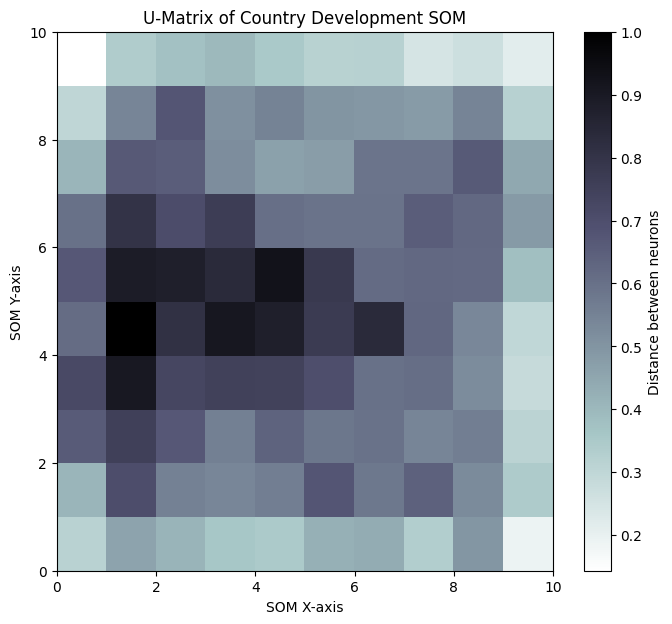

In [ ]:
# Step 6: Train the Self-Organizing Map and visualize the U-Matrix

from minisom import MiniSom
import matplotlib.pyplot as plt
import numpy as np


som_x = 10
som_y = 10


som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=X_scaled.shape[1],
    sigma=1.5,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    random_seed=42
)


som.random_weights_init(X_scaled)
som.train_random(X_scaled, num_iteration=5000, verbose=True)

print("SOM training completed.")
print("Quantization error:", som.quantization_error(X_scaled))
print("Topographic error:", som.topographic_error(X_scaled))


plt.figure(figsize=(8, 7))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance between neurons')
plt.title('U-Matrix of Country Development SOM')
plt.xlabel('SOM X-axis')
plt.ylabel('SOM Y-axis')
plt.show()

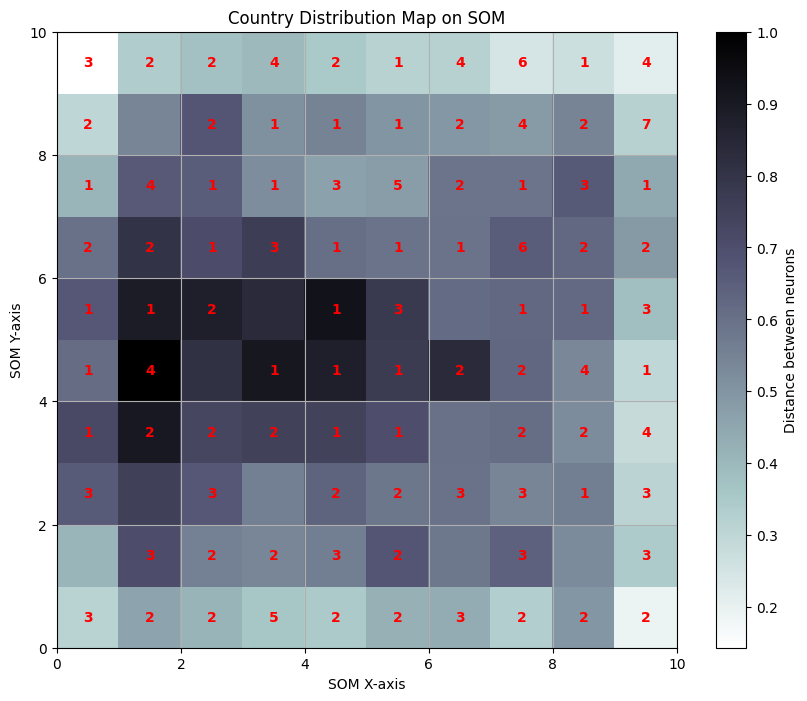

In [ ]:
# Step 7: Plot country distribution on the SOM grid

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

winners = [som.winner(x) for x in X_scaled]

winner_counts = Counter(winners)

plt.figure(figsize=(10, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance between neurons')

for position, count in winner_counts.items():
    plt.text(
        position[0] + 0.5,
        position[1] + 0.5,
        str(count),
        ha='center',
        va='center',
        color='red',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Country Distribution Map on SOM')
plt.xlabel('SOM X-axis')
plt.ylabel('SOM Y-axis')
plt.xlim(0, som_x)
plt.ylim(0, som_y)
plt.grid()
plt.show()

In [ ]:
# Show a few example countries and their winning neurons

country_winner_df = df_clean[['name', 'region']].copy()
country_winner_df['winner'] = winners

print(country_winner_df.head(10))

                  name           region  winner
0          Afghanistan    Southern Asia  (2, 2)
1              Albania  Southern Europe  (0, 9)
2              Algeria  Northern Africa  (5, 5)
3              Andorra  Southern Europe  (3, 9)
4               Angola    Middle Africa  (1, 1)
5  Antigua And Barbuda        Caribbean  (5, 7)
6            Argentina    South America  (7, 6)
7              Armenia     Western Asia  (1, 7)
8            Australia          Oceania  (9, 8)
9              Austria   Western Europe  (7, 8)


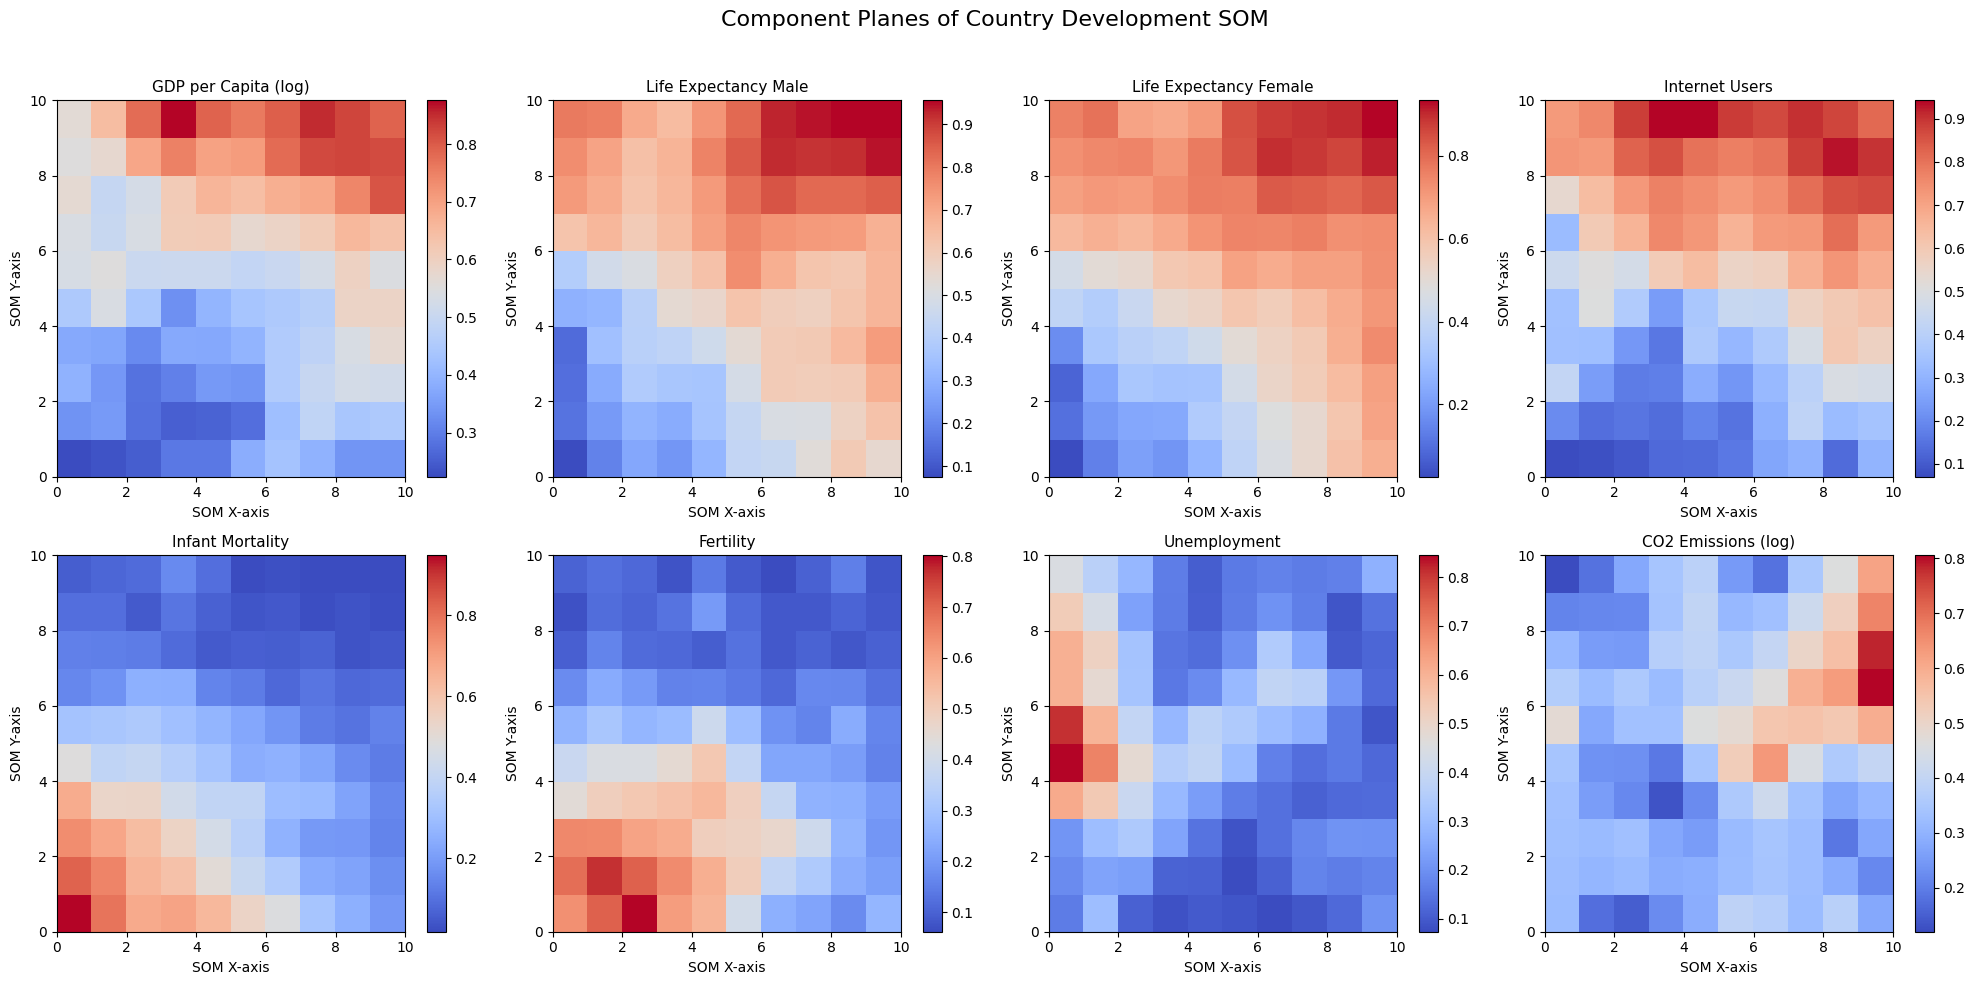

In [ ]:
# Step 8: Component planes for each feature

import matplotlib.pyplot as plt

weights = som.get_weights()

feature_titles = [
    'GDP per Capita (log)',
    'Life Expectancy Male',
    'Life Expectancy Female',
    'Internet Users',
    'Infant Mortality',
    'Fertility',
    'Unemployment',
    'CO2 Emissions (log)'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, ax in enumerate(axes.flat):
    im = ax.pcolor(weights[:, :, i].T, cmap='coolwarm')
    ax.set_title(feature_titles[i], fontsize=11)
    ax.set_xlabel('SOM X-axis')
    ax.set_ylabel('SOM Y-axis')
    plt.colorbar(im, ax=ax)

plt.suptitle('Component Planes of Country Development SOM', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

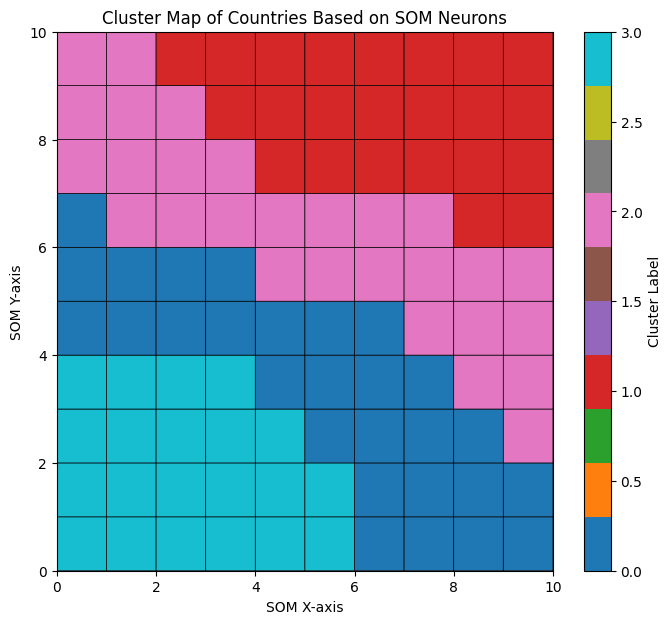

In [ ]:
# Step 9: Cluster the SOM neurons using K-Means

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

weights_2d = weights.reshape(-1, X_scaled.shape[1])

n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
neuron_clusters = kmeans.fit_predict(weights_2d)

cluster_map = neuron_clusters.reshape(som_x, som_y)

plt.figure(figsize=(8, 7))
plt.pcolor(cluster_map.T, cmap='tab10', edgecolors='k', linewidths=0.5)
plt.colorbar(label='Cluster Label')
plt.title('Cluster Map of Countries Based on SOM Neurons')
plt.xlabel('SOM X-axis')
plt.ylabel('SOM Y-axis')
plt.xlim(0, som_x)
plt.ylim(0, som_y)
plt.show()

In [ ]:
# Step 9B: Assign each country to a cluster based on its winning neuron

country_clusters = []
winner_coordinates = []

for x in X_scaled:
    winner = som.winner(x)
    winner_coordinates.append(winner)
    country_clusters.append(cluster_map[winner[0], winner[1]])

df_results = df_clean[['name', 'region'] + som_features].copy()
df_results['winner_neuron'] = winner_coordinates
df_results['cluster'] = country_clusters

print("First 15 countries with assigned clusters:")
display(df_results[['name', 'region', 'winner_neuron', 'cluster']].head(15))

print("\nNumber of countries in each cluster:")
print(df_results['cluster'].value_counts().sort_index())

First 15 countries with assigned clusters:


,name,region,winner_neuron,cluster
0,Afghanistan,Southern Asia,"(2, 2)",3
1,Albania,Southern Europe,"(0, 9)",2
2,Algeria,Northern Africa,"(5, 5)",2
3,Andorra,Southern Europe,"(3, 9)",1
4,Angola,Middle Africa,"(1, 1)",3
5,Antigua And Barbuda,Caribbean,"(5, 7)",1
6,Argentina,South America,"(7, 6)",2
7,Armenia,Western Asia,"(1, 7)",2
8,Australia,Oceania,"(9, 8)",1
9,Austria,Western Europe,"(7, 8)",1



Number of countries in each cluster:
cluster
0    44
1    61
2    56
3    43
Name: count, dtype: int64


In [ ]:
# Step 9C: Check duplicate country names

print("Total rows:", len(df_results))
print("Unique country names:", df_results['name'].nunique())

duplicate_countries = df_results[df_results.duplicated(subset='name', keep=False)]

print("\nNumber of duplicated rows based on country name:", len(duplicate_countries))

if len(duplicate_countries) > 0:
    print("\nDuplicated countries:")
    display(duplicate_countries[['name', 'region', 'winner_neuron', 'cluster']].sort_values('name'))
else:
    print("\nNo duplicated country names found.")

Total rows: 204
Unique country names: 192

Number of duplicated rows based on country name: 24

Duplicated countries:


,name,region,winner_neuron,cluster
0,Afghanistan,Southern Asia,"(2, 2)",3
10,Afghanistan,Southern Asia,"(2, 2)",3
11,Albania,Southern Europe,"(0, 9)",2
1,Albania,Southern Europe,"(0, 9)",2
2,Algeria,Northern Africa,"(5, 5)",2
12,Algeria,Northern Africa,"(5, 5)",2
3,Andorra,Southern Europe,"(3, 9)",1
13,Andorra,Southern Europe,"(3, 9)",1
4,Angola,Middle Africa,"(1, 1)",3
14,Angola,Middle Africa,"(1, 1)",3


In [ ]:
# Step 9D: Remove duplicated countries

df_selected = df_selected.drop_duplicates(subset='name', keep='first').reset_index(drop=True)

print("Dataset shape after removing duplicates:", df_selected.shape)
print("Unique country names:", df_selected['name'].nunique())

print("\nChecking duplicates again:")
print(df_selected[df_selected.duplicated(subset='name', keep=False)])

Dataset shape after removing duplicates: (192, 10)
Unique country names: 192

Checking duplicates again:
Empty DataFrame
Columns: [name, region, gdp_per_capita, life_expectancy_male, life_expectancy_female, internet_users, infant_mortality, fertility, unemployment, co2_emissions]
Index: []


Missing values after cleaning:
name                      0
region                    0
gdp_per_capita            0
life_expectancy_male      0
life_expectancy_female    0
internet_users            0
infant_mortality          0
fertility                 0
unemployment              0
co2_emissions             0
dtype: int64

Final data shape for SOM: (192, 8)
 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.12938780996758292

SOM training completed.
Quantization error: 0.12938780996758292
Topographic error: 0.057291666666666664


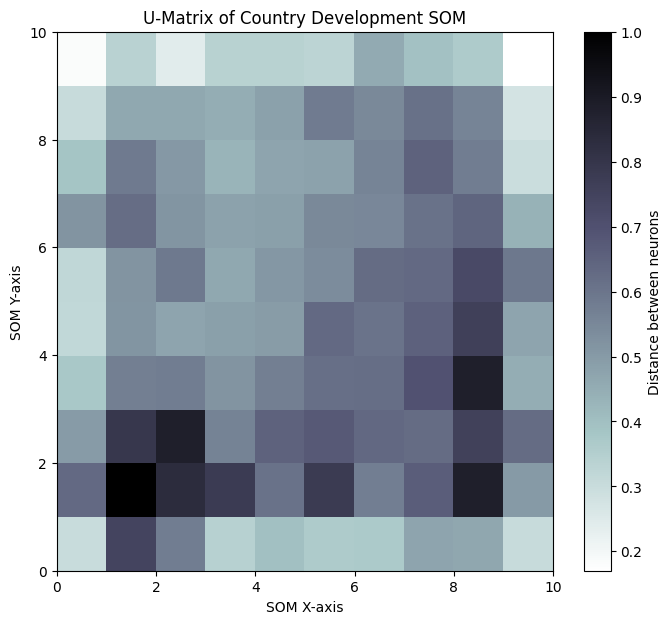

In [ ]:
# Step 10: Re-run preprocessing and SOM training after removing duplicates

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

selected_features = [
    'gdp_per_capita',
    'life_expectancy_male',
    'life_expectancy_female',
    'internet_users',
    'infant_mortality',
    'fertility',
    'unemployment',
    'co2_emissions'
]

df_clean = df_selected.copy()

for col in selected_features:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())


df_clean['gdp_per_capita_log'] = np.log1p(df_clean['gdp_per_capita'])
df_clean['co2_emissions_log'] = np.log1p(df_clean['co2_emissions'])


som_features = [
    'gdp_per_capita_log',
    'life_expectancy_male',
    'life_expectancy_female',
    'internet_users',
    'infant_mortality',
    'fertility',
    'unemployment',
    'co2_emissions_log'
]


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_clean[som_features])

print("\nFinal data shape for SOM:", X_scaled.shape)


som_x = 10
som_y = 10

som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=X_scaled.shape[1],
    sigma=1.5,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    random_seed=42
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, num_iteration=5000, verbose=True)

print("\nSOM training completed.")
print("Quantization error:", som.quantization_error(X_scaled))
print("Topographic error:", som.topographic_error(X_scaled))


plt.figure(figsize=(8, 7))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance between neurons')
plt.title('U-Matrix of Country Development SOM')
plt.xlabel('SOM X-axis')
plt.ylabel('SOM Y-axis')
plt.show()

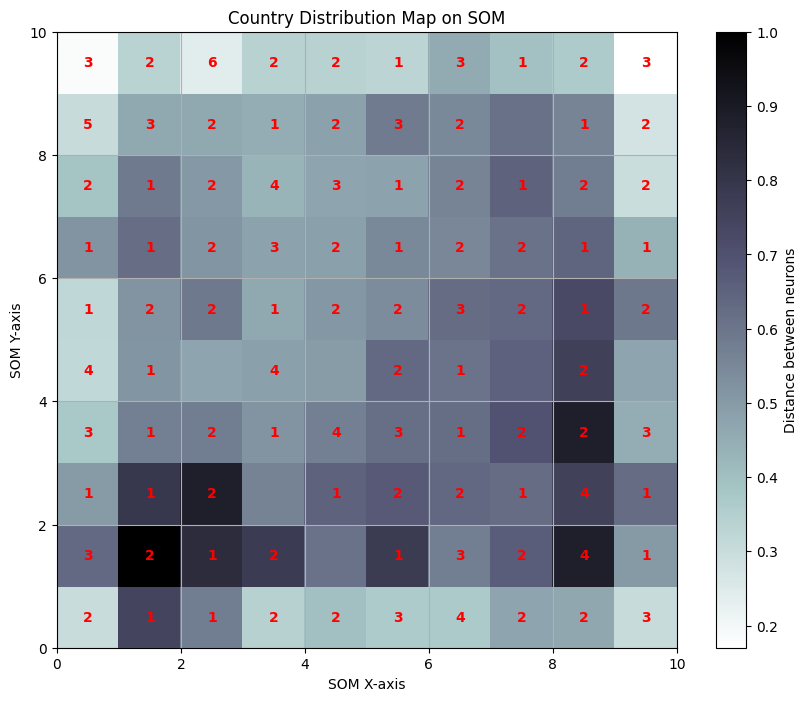

First 10 countries and their winning neurons:


,name,region,winner
0,Afghanistan,Southern Asia,"(8, 2)"
1,Albania,Southern Europe,"(9, 9)"
2,Algeria,Northern Africa,"(0, 3)"
3,Andorra,Southern Europe,"(6, 9)"
4,Angola,Middle Africa,"(8, 1)"
5,Antigua And Barbuda,Caribbean,"(4, 7)"
6,Argentina,South America,"(0, 4)"
7,Armenia,Western Asia,"(8, 7)"
8,Australia,Oceania,"(0, 8)"
9,Austria,Western Europe,"(1, 8)"


In [ ]:
# Step 11: Country distribution map with cleaned dataset

from collections import Counter
import matplotlib.pyplot as plt

winners = [som.winner(x) for x in X_scaled]

winner_counts = Counter(winners)


plt.figure(figsize=(10, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance between neurons')

for position, count in winner_counts.items():
    plt.text(
        position[0] + 0.5,
        position[1] + 0.5,
        str(count),
        ha='center',
        va='center',
        color='red',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Country Distribution Map on SOM')
plt.xlabel('SOM X-axis')
plt.ylabel('SOM Y-axis')
plt.xlim(0, som_x)
plt.ylim(0, som_y)
plt.grid()
plt.show()

country_winner_df = df_clean[['name', 'region']].copy()
country_winner_df['winner'] = winners

print("First 10 countries and their winning neurons:")
display(country_winner_df.head(10))

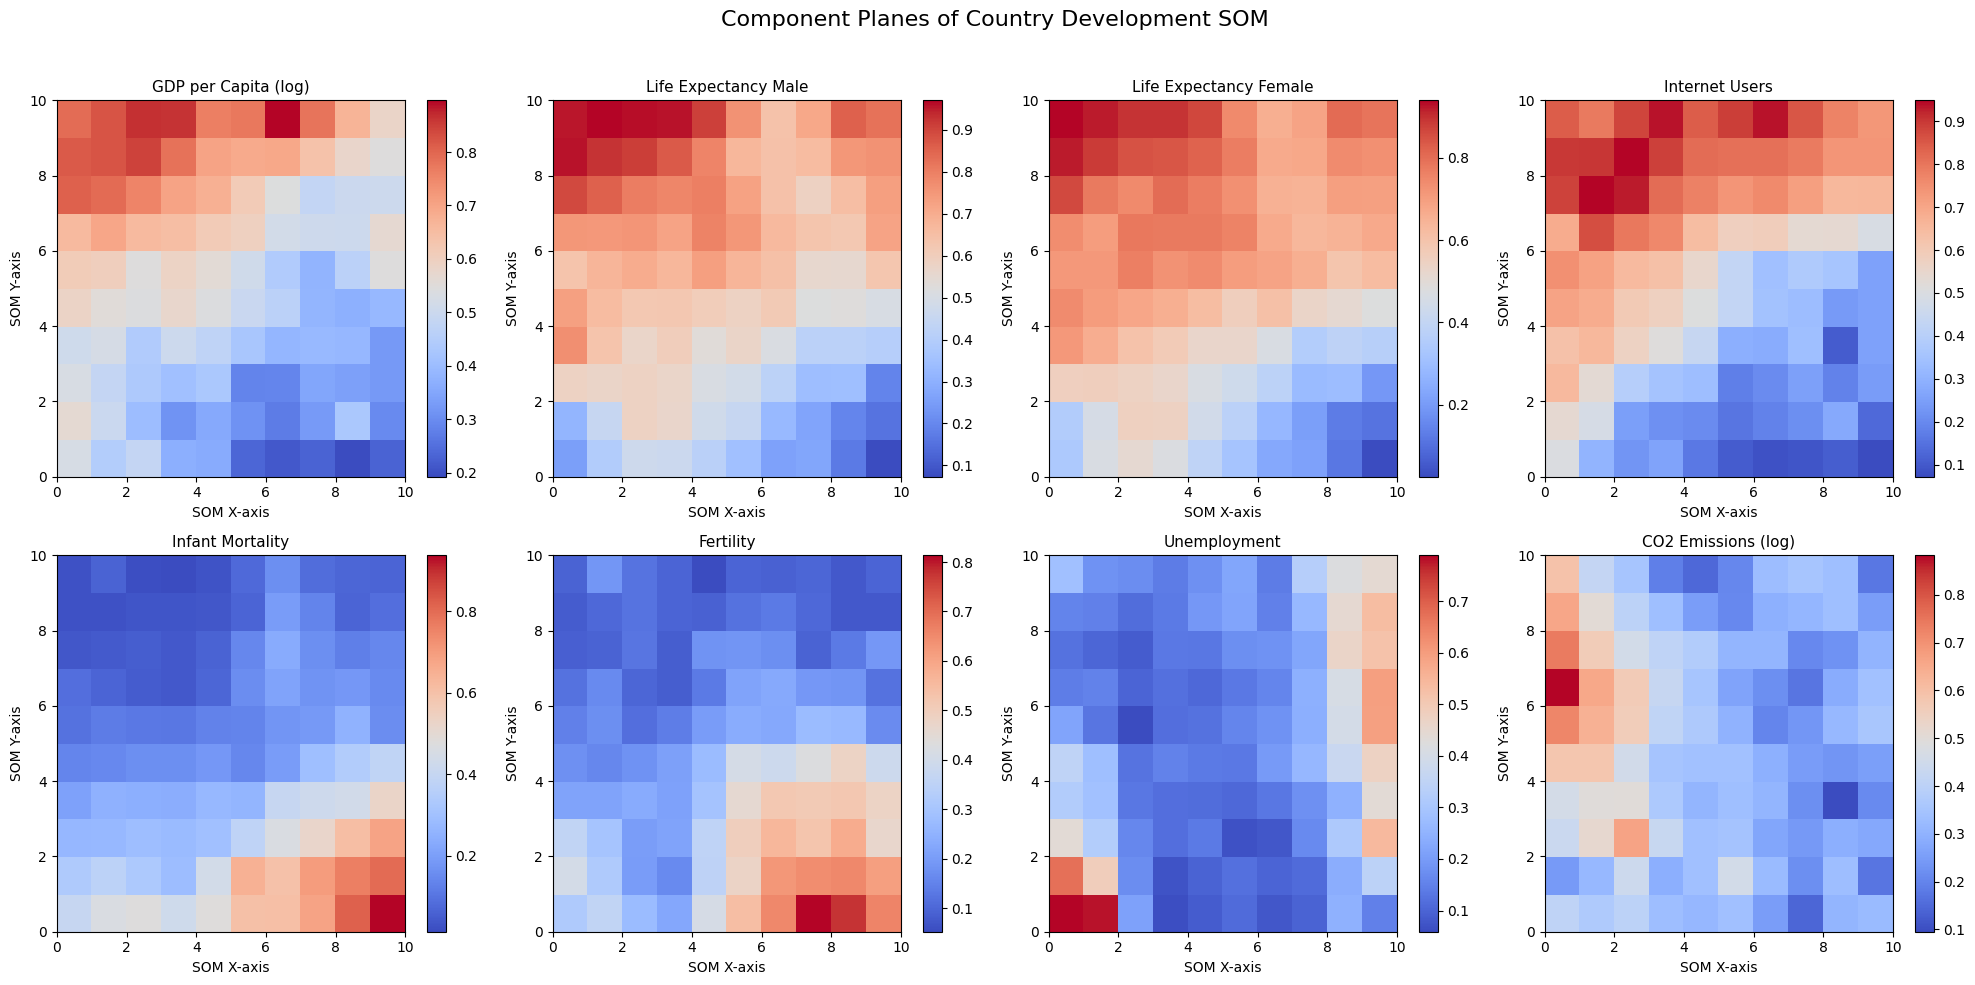

In [ ]:
# Step 12: Final component planes using cleaned dataset

import matplotlib.pyplot as plt

weights = som.get_weights()

feature_titles = [
    'GDP per Capita (log)',
    'Life Expectancy Male',
    'Life Expectancy Female',
    'Internet Users',
    'Infant Mortality',
    'Fertility',
    'Unemployment',
    'CO2 Emissions (log)'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, ax in enumerate(axes.flat):
    im = ax.pcolor(weights[:, :, i].T, cmap='coolwarm')
    ax.set_title(feature_titles[i], fontsize=11)
    ax.set_xlabel('SOM X-axis')
    ax.set_ylabel('SOM Y-axis')
    plt.colorbar(im, ax=ax)

plt.suptitle('Component Planes of Country Development SOM', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

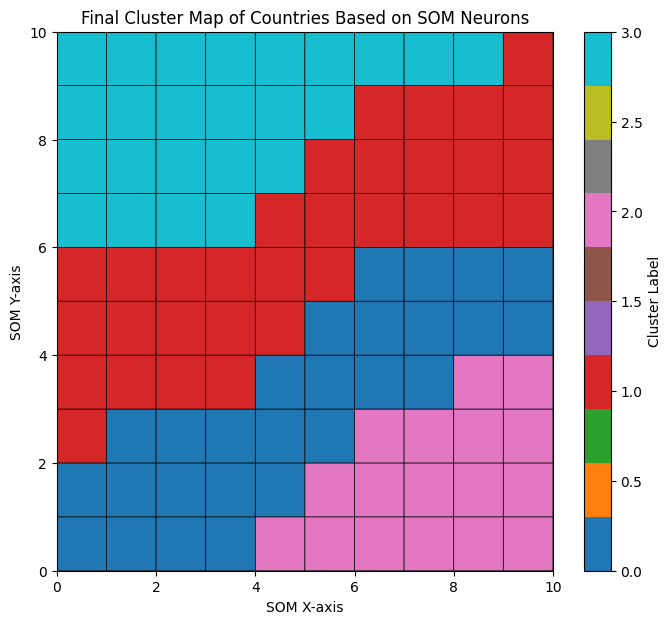

In [ ]:
# Step 13: Final cluster map using cleaned dataset

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

weights = som.get_weights()

weights_2d = weights.reshape(-1, X_scaled.shape[1])

n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
neuron_clusters = kmeans.fit_predict(weights_2d)

cluster_map = neuron_clusters.reshape(som_x, som_y)

plt.figure(figsize=(8, 7))
plt.pcolor(cluster_map.T, cmap='tab10', edgecolors='k', linewidths=0.5)
plt.colorbar(label='Cluster Label')
plt.title('Final Cluster Map of Countries Based on SOM Neurons')
plt.xlabel('SOM X-axis')
plt.ylabel('SOM Y-axis')
plt.xlim(0, som_x)
plt.ylim(0, som_y)
plt.show()

In [ ]:
# Step 13B: Assign each country to a cluster

country_clusters = []
winner_coordinates = []

for x in X_scaled:
    winner = som.winner(x)
    winner_coordinates.append(winner)
    country_clusters.append(cluster_map[winner[0], winner[1]])

df_results = df_clean[['name', 'region'] + som_features].copy()
df_results['winner_neuron'] = winner_coordinates
df_results['cluster'] = country_clusters

print("First 15 countries with assigned clusters:")
display(df_results[['name', 'region', 'winner_neuron', 'cluster']].head(15))

print("\nNumber of countries in each cluster:")
print(df_results['cluster'].value_counts().sort_index())

First 15 countries with assigned clusters:


,name,region,winner_neuron,cluster
0,Afghanistan,Southern Asia,"(8, 2)",2
1,Albania,Southern Europe,"(9, 9)",1
2,Algeria,Northern Africa,"(0, 3)",1
3,Andorra,Southern Europe,"(6, 9)",3
4,Angola,Middle Africa,"(8, 1)",2
5,Antigua And Barbuda,Caribbean,"(4, 7)",3
6,Argentina,South America,"(0, 4)",1
7,Armenia,Western Asia,"(8, 7)",1
8,Australia,Oceania,"(0, 8)",3
9,Austria,Western Europe,"(1, 8)",3



Number of countries in each cluster:
cluster
0    43
1    52
2    40
3    57
Name: count, dtype: int64


In [ ]:
# Step 14: Cluster summary table using original feature values

summary_features = [
    'gdp_per_capita',
    'life_expectancy_male',
    'life_expectancy_female',
    'internet_users',
    'infant_mortality',
    'fertility',
    'unemployment',
    'co2_emissions'
]


df_cluster_summary = df_clean[['name', 'region'] + summary_features].copy()
df_cluster_summary['cluster'] = df_results['cluster']


cluster_summary = df_cluster_summary.groupby('cluster')[summary_features].mean().round(2)

print("Cluster summary table:")
display(cluster_summary)

print("\nNumber of countries in each cluster:")
display(df_cluster_summary['cluster'].value_counts().sort_index())

Cluster summary table:


,gdp_per_capita,life_expectancy_male,life_expectancy_female,internet_users,infant_mortality,fertility,unemployment,co2_emissions
cluster,,,,,,,,
0,3501.42,66.63,71.80,34.85,25.14,3.10,8.81,99.22
1,7424.72,71.94,77.66,64.51,13.46,2.12,8.12,113.76
2,1353.91,59.37,62.72,16.47,53.71,4.67,6.27,24.92
3,41964.72,76.98,81.92,85.49,5.02,1.71,5.36,379.50



Number of countries in each cluster:


,count
cluster,
0,43
1,52
2,40
3,57


In [ ]:
# Step 14B: Show example countries from each cluster

for cluster_id in sorted(df_cluster_summary['cluster'].unique()):
    print(f"\nCluster {cluster_id} example countries:")
    examples = df_cluster_summary[df_cluster_summary['cluster'] == cluster_id][['name', 'region']].head(12)
    display(examples)


Cluster 0 example countries:


,name,region
13,Bangladesh,Southern Asia
20,"Bolivia, Plurinational State Of",South America
22,Botswana,Southern Africa
29,Cambodia,South-Eastern Asia
46,Djibouti,Eastern Africa
49,Timor-Leste,South-Eastern Asia
51,Egypt,Northern Africa
52,El Salvador,Central America
56,Swaziland,Southern Africa
58,Fiji,Melanesia



Cluster 1 example countries:


,name,region
1,Albania,Southern Europe
2,Algeria,Northern Africa
6,Argentina,South America
7,Armenia,Western Asia
10,Azerbaijan,Western Asia
17,Belize,Central America
19,Bhutan,Southern Asia
21,Bosnia And Herzegovina,Southern Europe
23,Brazil,South America
25,Bulgaria,Eastern Europe



Cluster 2 example countries:


,name,region
0,Afghanistan,Southern Asia
4,Angola,Middle Africa
18,Benin,Western Africa
26,Burkina Faso,Western Africa
27,Burundi,Eastern Africa
30,Cameroon,Middle Africa
32,Central African Republic,Middle Africa
33,Chad,Middle Africa
37,Comoros,Eastern Africa
38,Congo,Middle Africa



Cluster 3 example countries:


,name,region
3,Andorra,Southern Europe
5,Antigua And Barbuda,Caribbean
8,Australia,Oceania
9,Austria,Western Europe
11,Bahamas,Caribbean
12,Bahrain,Western Asia
14,Barbados,Caribbean
15,Belarus,Eastern Europe
16,Belgium,Western Europe
24,Brunei Darussalam,South-Eastern Asia


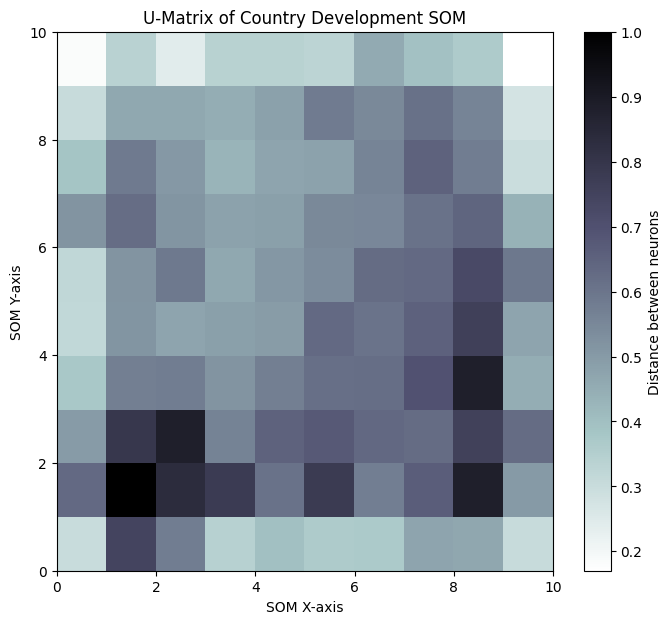

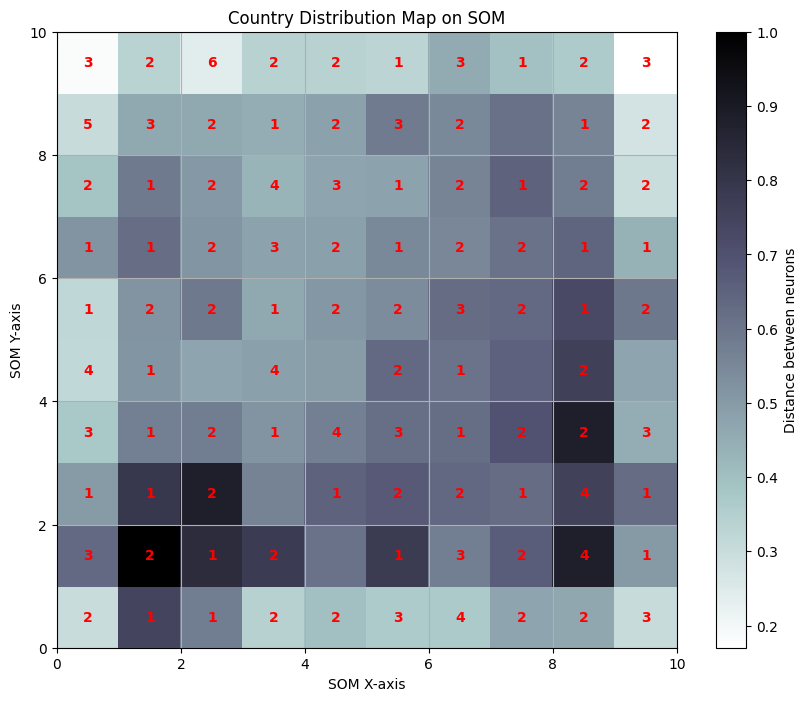

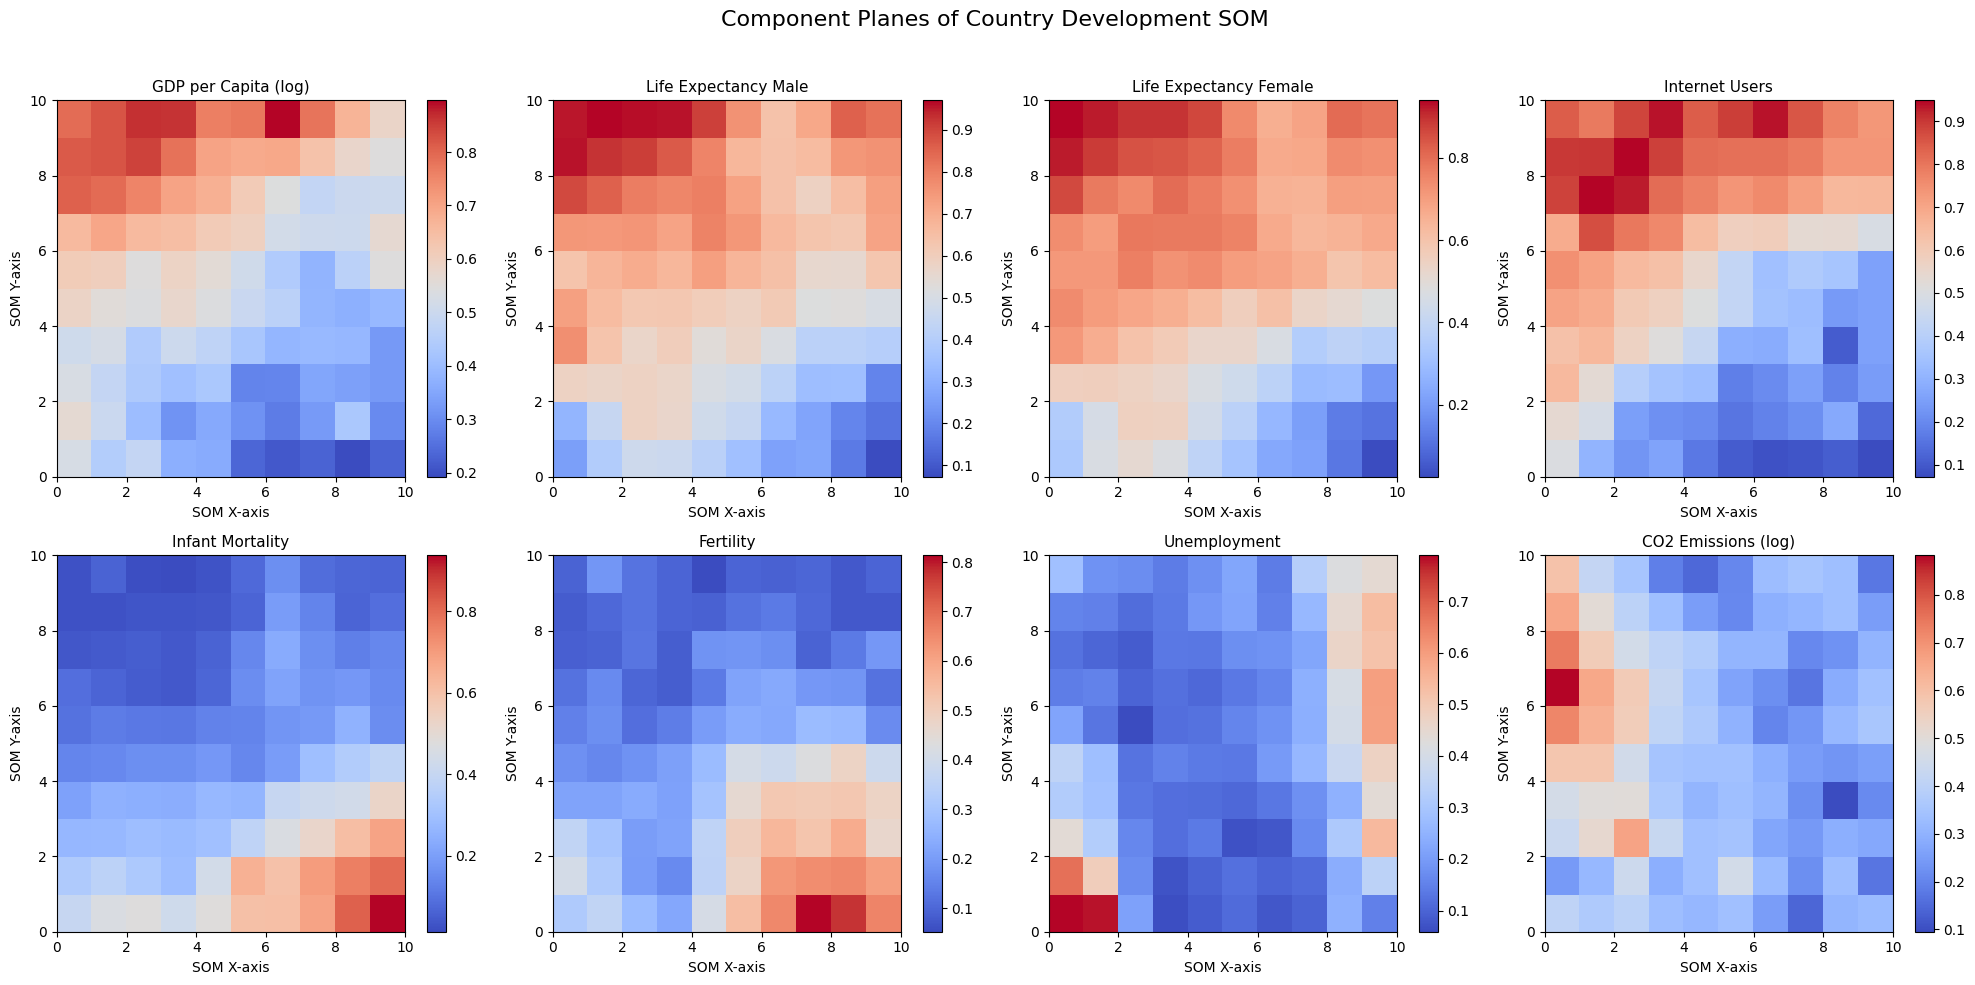

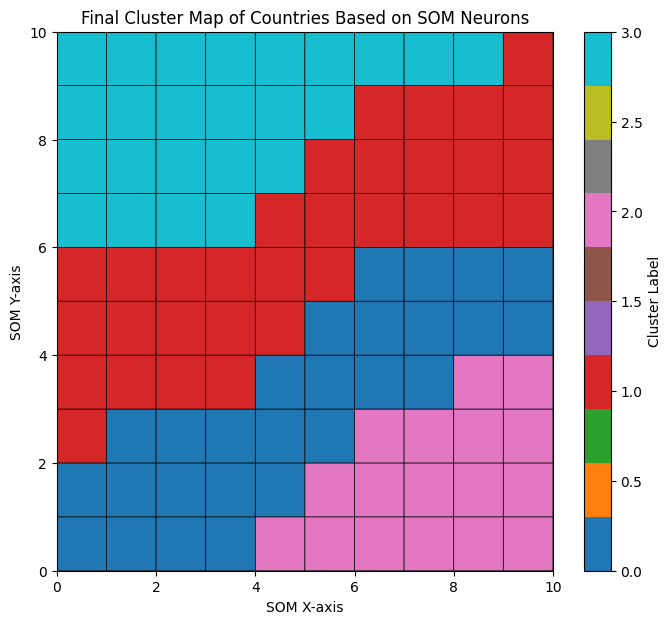

All figures and tables were saved successfully.
ZIP file location: /content/som_assignment_outputs.zip
Files saved:
['cluster_summary_table.csv', 'figure_4_cluster_map.png', 'country_cluster_assignments.csv', 'figure_1_u_matrix.png', 'figure_2_country_distribution_map.png', 'figure_3_component_planes.png']


In [ ]:
# Step 15: Save final visual outputs and result tables

import os
import zipfile
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

output_dir = "/content/som_assignment_outputs"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(8, 7))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance between neurons')
plt.title('U-Matrix of Country Development SOM')
plt.xlabel('SOM X-axis')
plt.ylabel('SOM Y-axis')
plt.savefig(f"{output_dir}/figure_1_u_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

winners = [som.winner(x) for x in X_scaled]
winner_counts = Counter(winners)

plt.figure(figsize=(10, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance between neurons')

for position, count in winner_counts.items():
    plt.text(
        position[0] + 0.5,
        position[1] + 0.5,
        str(count),
        ha='center',
        va='center',
        color='red',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Country Distribution Map on SOM')
plt.xlabel('SOM X-axis')
plt.ylabel('SOM Y-axis')
plt.xlim(0, som_x)
plt.ylim(0, som_y)
plt.grid()
plt.savefig(f"{output_dir}/figure_2_country_distribution_map.png", dpi=300, bbox_inches='tight')
plt.show()

weights = som.get_weights()

feature_titles = [
    'GDP per Capita (log)',
    'Life Expectancy Male',
    'Life Expectancy Female',
    'Internet Users',
    'Infant Mortality',
    'Fertility',
    'Unemployment',
    'CO2 Emissions (log)'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, ax in enumerate(axes.flat):
    im = ax.pcolor(weights[:, :, i].T, cmap='coolwarm')
    ax.set_title(feature_titles[i], fontsize=11)
    ax.set_xlabel('SOM X-axis')
    ax.set_ylabel('SOM Y-axis')
    plt.colorbar(im, ax=ax)

plt.suptitle('Component Planes of Country Development SOM', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{output_dir}/figure_3_component_planes.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 7))
plt.pcolor(cluster_map.T, cmap='tab10', edgecolors='k', linewidths=0.5)
plt.colorbar(label='Cluster Label')
plt.title('Final Cluster Map of Countries Based on SOM Neurons')
plt.xlabel('SOM X-axis')
plt.ylabel('SOM Y-axis')
plt.xlim(0, som_x)
plt.ylim(0, som_y)
plt.savefig(f"{output_dir}/figure_4_cluster_map.png", dpi=300, bbox_inches='tight')
plt.show()

cluster_summary.to_csv(f"{output_dir}/cluster_summary_table.csv")
df_cluster_summary.to_csv(f"{output_dir}/country_cluster_assignments.csv", index=False)

zip_path = "/content/som_assignment_outputs.zip"

with zipfile.ZipFile(zip_path, 'w') as zipf:
    for file_name in os.listdir(output_dir):
        file_path = os.path.join(output_dir, file_name)
        zipf.write(file_path, arcname=file_name)

print("All figures and tables were saved successfully.")
print("ZIP file location:", zip_path)
print("Files saved:")
print(os.listdir(output_dir))